# 07 - Modelos Preentrenados con Hugging Face

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es explorar y utilizar modelos preentrenados de última generación en visión por computadora a través del ecosistema oficial de Hugging Face. Analizaremos cómo transferir el conocimiento de modelos robustos ya entrenados en enormes conjuntos de datos para resolver tareas de clasificación general, clasificación zero-shot flexible y detección espacial de múltiples objetos en imágenes cotidianas.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Cargar y utilizar pipelines de inferencia de Hugging Face de manera ágil y eficiente.
2. Clasificar imágenes complejas utilizando la arquitectura Vision Transformer (ViT).
3. Aplicar clasificación zero-shot con CLIP para evaluar categorías personalizadas mediante lenguaje natural.
4. Detectar y localizar de forma espacial múltiples objetos de forma de simultánea utilizando DETR.
5. Comparar las ventajas de velocidad, flexibilidad y precisión espacial entre diferentes modelos de visión.

## Terminología clave (Microglosario)

*   **Modelos Preentrenados:** Redes neuronales ya optimizadas en gigantescos conjuntos de datos por laboratorios de investigación, listas para ser usadas directamente o adaptadas. *Como un diccionario ya impreso: no necesitamos escribir cada entrada, solo consultamos la que nos hace falta.*
*   **Transformers en Visión (ViT):** Arquitectura que adapta los mecanismos de autoatención dividiendo la imagen en parches (*patches*) y analizando las relaciones entre ellos, en lugar de utilizar convoluciones locales. *Como un lector que divide un texto en párrafos y evalúa qué tan relevante es cada párrafo para entender el todo, en vez de analizar cada letra por separado.*
*   **Clasificación Zero-Shot:** Capacidad de una red de clasificar muestras en categorías personalizadas que el modelo no ha visto explícitamente durante un entrenamiento específico. *Como un sommelier experimentado que identifica la región de un vino nunca probado, solo por sus características: el conocimiento general permite razonar sobre lo nuevo.*
*   **Detección de Objetos:** Tarea de localizar espacialmente múltiples elementos en una escena indicando su etiqueta categórica y coordenadas exactas (*bounding boxes*). *Como un guardia de seguridad que no solo dice "hay personas en la sala" sino que dibuja un círculo alrededor de cada una y las etiqueta con su función.*
*   **Pipeline de Inferencia:** Abstracción simplificada que encapsula la carga del modelo, preprocesamiento de entradas e interpretación de salidas en pocas instrucciones de código. *Como el mecanismo completo de un cajero automático: insertamos la tarjeta y salimos con efectivo sin ver el sistema bancario, la encriptación ni los servidores que operaron en el medio.*

## 1. Configuración del Entorno de Ejecución

Procederemos con la instalación silenciosa de las librerías necesarias del ecosistema PyTorch y Hugging Face para trabajar con los pesos y arquitecturas oficiales.

In [1]:
print('✦ Instalando dependencias del ecosistema Hugging Face en el sistema...')
# Realizamos la instalación silenciando la salida didáctica redundante
!pip install transformers torch pillow requests matplotlib -q
print('✓ Dependencias de Deep Learning y Visión instaladas con éxito.')

✦ Instalando dependencias del ecosistema Hugging Face en el sistema...
✓ Dependencias de Deep Learning y Visión instaladas con éxito.


In [2]:
import torch
from transformers import pipeline
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

print('✓ Librerías esenciales importadas correctamente.')
print(f'  • Versión de PyTorch: {torch.__version__}')
print('✦ Ecosistema listo para desplegar modelos preentrenados.')

✓ Librerías esenciales importadas correctamente.
  • Versión de PyTorch: 2.12.0+cpu
✦ Ecosistema listo para desplegar modelos preentrenados.


## 2. Funciones Auxiliares de Carga y Manejo de Imágenes

Definiremos funciones genéricas para cargar imágenes, tanto desde URLs públicas como desde el almacenamiento local, garantizando la compatibilidad tanto en Google Colab como en servidores locales de Jupyter.

In [3]:
def cargar_imagen_local():
    """
    Permite subir una imagen local de forma interactiva en Colab o mediante
    un selector de archivos en VS Code/Jupyter local.
    Retorna: imagen cargada en formato PIL
    """
    try:
        from google.colab import files
        print('✦ Subiendo archivo desde Google Colab...')
        cargas = files.upload()
        nombre_archivo = list(cargas.keys())[0]
        imagen = Image.open(nombre_archivo)
        print(f'✓ Imagen cargada: {nombre_archivo}')
        return imagen
    except Exception:
        print('✦ Entorno local detectado. Abriendo selector de archivo...')
        try:
            import tkinter as tk
            from tkinter import filedialog

            raiz = tk.Tk()
            raiz.withdraw()
            raiz.attributes('-topmost', True)
            ruta_local = filedialog.askopenfilename(
                title='Seleccionen una imagen',
                filetypes=[
                    ('Imágenes', '*.png *.jpg *.jpeg *.bmp *.gif *.webp'),
                    ('Todos los archivos', '*.*')
                ]
            )
            raiz.destroy()
        except Exception:
            ruta_local = input('Por favor, ingresen la ruta local de la imagen (ej: ./mi_imagen.jpg): ')

        if ruta_local and os.path.exists(ruta_local):
            imagen = Image.open(ruta_local)
            print(f'✓ Imagen cargada: {ruta_local}')
            return imagen
        else:
            print(f'✗ Error: No se encontró archivo en {ruta_local}')
            return None

def cargar_imagen_url(url):
    """
    Carga una imagen remota a partir de una dirección URL pública.
    """
    try:
        respuesta = requests.get(url, timeout=10)
        respuesta.raise_for_status()
        imagen = Image.open(BytesIO(respuesta.content))
        print('✓ Imagen remota cargada con éxito.')
        print(f'  • Resolución original: {imagen.size}')
        return imagen
    except Exception as e:
        print(f'✗ Error de red al cargar la imagen: {e}')
        return None

def mostrar_resultados(imagen, resultados, titulo='Predicciones'):
    """
    Grafica la imagen de forma elegante junto a las barras de confianza del modelo.
    """
    plt.figure(figsize=(12, 5))
    
    # Dibujamos la imagen
    plt.subplot(1, 2, 1)
    plt.imshow(imagen)
    plt.title(titulo, fontsize=13, fontweight='bold', pad=15)
    plt.axis('off')
    
    # Dibujamos las barras analíticas
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    texto_analitico = ''
    primeras_cinco = resultados[:5]
    for i in range(len(primeras_cinco)):
        res = primeras_cinco[i]
        numero = i + 1
        if isinstance(res, dict):
            etiqueta = res.get('label', 'Desconocido')
            probabilidad = res.get('score', 0.0)
            porcentaje = f'{probabilidad:.1%}'
            barra_visual = '█' * int(probabilidad * 20)
            texto_analitico += f'{numero}. {etiqueta}\n'
            texto_analitico += f'   Confianza: {porcentaje} {barra_visual}\n\n'
            
    plt.text(
        0.05, 0.95, texto_analitico, fontsize=11,
        verticalalignment='top', horizontalalignment='left',
        family='monospace',
        bbox=dict(boxstyle='round,pad=1', facecolor='aliceblue', alpha=0.9)
    )
    plt.tight_layout()
    plt.show()

print('✓ Funciones de asistencia visual definidas con éxito.')

✓ Funciones de asistencia visual definidas con éxito.


## ✦ Antes de cargar los modelos: cómo ve una imagen el Vision Transformer

Las CNN que usamos antes analizan la imagen con filtros que se deslizan píxel a píxel en ventanas locales. El **Vision Transformer (ViT)** adopta una estrategia radicalmente diferente:

1. **Divide la imagen en parches.** Una imagen de 224×224 px se divide en **196 parches** cuadrados de 16×16 px cada uno.
2. **Aplana cada parche en un vector.** Cada parche de 16×16×3 canales se convierte en un vector de 768 números.
3. **Procesa la secuencia con atención.** Los 196 vectores se analizan como si fueran palabras de una oración: el modelo aprende qué parches son más relevantes entre sí para decidir la categoría final.

```
Imagen 224×224 px                   196 parches de 16×16 px
┌──────────────────┐                ┌──┬──┬──┬── ···
│                  │   divide en    │P1│P2│P3│
│   (imagen RGB)   │  ──────────►   ├──┼──┼──┼──
│                  │                │  │  │  │ ···
└──────────────────┘                └──┴──┴──┴──
                                          │
                              secuencia de 196 vectores
                                          │
                                  mecanismo de atención
                                          │
                              etiqueta + confianza (top-5)
```

Esta arquitectura permite detectar relaciones entre regiones lejanas de la imagen, algo que las convoluciones locales no logran directamente. CLIP y DETR extienden esta idea al lenguaje natural y a la localización espacial, respectivamente.

## ✦ MODELO 1: Vision Transformer (ViT)

El modelo **Vision Transformer (ViT)** representa un hito en la visión artificial moderna, aplicando la arquitectura de autoatención originalmente diseñada para textos directo en parches rectangulares de imágenes como si fueran tokens lingüísticos secuenciales.

In [4]:
print('✦ Descargando pesos oficiales de Google Vision Transformer (vit-base-patch16-224)...')
print('  (Este paso puede tardar un momento)')

# Instanciamos el pipeline simplificado para clasificación general
clasificador_vit = pipeline(
    'image-classification',
    model='google/vit-base-patch16-224'
)

print('\n✓ Vision Transformer instanciado y listo para inferir.')
print('  • Modelo entrenado en ImageNet (1000 categorías biológicas y de objetos).')

✦ Descargando pesos oficiales de Google Vision Transformer (vit-base-patch16-224)...
  (Este paso puede tardar un momento)


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

c:\Users\Cynthia\Desktop\ifts24-lab-pdi-2026-CYNTHIA\venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Cynthia\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]


✓ Vision Transformer instanciado y listo para inferir.
  • Modelo entrenado en ImageNet (1000 categorías biológicas y de objetos).


## 3.1. Pruebas Experimentales con ViT

Alimentaremos al modelo ViT con una imagen de prueba de Internet para analizar su capacidad predictiva.

✓ Imagen remota cargada con éxito.
  • Resolución original: (1200, 800)
✦ Evaluando la imagen con ViT...

Top 5 Inferencias de ImageNet:
---------------------------------------------
1. flamingo                  → Confianza: 94.2%
2. black stork, Ciconia nigra → Confianza: 3.4%
3. American egret, great white heron, Egretta albus → Confianza: 0.2%
4. pelican                   → Confianza: 0.2%
5. crane                     → Confianza: 0.2%


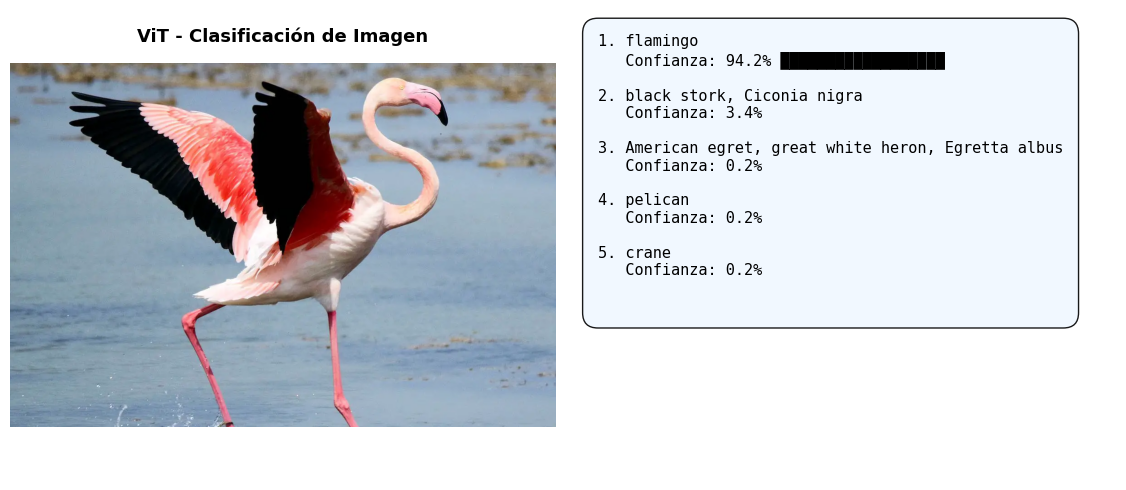

In [ ]:
url_flamenco = 'https://atlasanimal.com/wp-content/uploads/2021/02/flamenco.jpg'
imagen = cargar_imagen_url(url_flamenco)

if imagen:
    print('✦ Evaluando la imagen con ViT...')
    predicciones_vit = clasificador_vit(imagen)
    
    print('\nTop 5 Inferencias de ImageNet:')
    print('-' * 45)
    primeras_cinco = predicciones_vit[:5]
    for i in range(len(primeras_cinco)):
        numero = i + 1
        prediccion = primeras_cinco[i]
        etiqueta = prediccion["label"]
        confianza = prediccion["score"]
        porcentaje = f'{confianza:.1%}'
        print(f'{numero}. {etiqueta:25s} → Confianza: {porcentaje}')
        
    # Mostramos los resultados de manera visual
    mostrar_resultados(imagen, predicciones_vit, 'ViT - Clasificación de Imagen')

In [ ]:
print("Antes del input")
valor = input("Ingresá algo: ")
print("Después del input:", valor)

In [ ]:
print('✦ Ejercicio interactivo: Clasifiquen su propia muestra local con ViT')
print('=' * 65)

confirmacion = input('¿Quieren subir una imagen desde su entorno local? (s/n): ').lower()

# if confirmacion == 's':
#     imagen_usuario = cargar_imagen_local()
    
#     if imagen_usuario:
#         print('✦ Clasificando la muestra ingresada...')
#         predicciones_usuario = clasificador_vit(imagen_usuario)
        
#         print('\nResultados de la Inferencia:')
#         print('-' * 45)
#         primeras_cinco = predicciones_usuario[:5]
#         for i in range(len(primeras_cinco)):
#             numero = i + 1
#             prediccion = primeras_cinco[i]
#             etiqueta = prediccion["label"]
#             confianza = prediccion["score"]
#             porcentaje = f'{confianza:.1%}'
#             print(f'{numero}. {etiqueta:25s} → {porcentaje}')
            
#         mostrar_resultados(imagen_usuario, predicciones_usuario, 'ViT - Su Muestra')
# else:
#     print('✦ Excelente. Continuemos con el siguiente modelo multimodal.')

✦ Ejercicio interactivo: Clasifiquen su propia muestra local con ViT


In [2]:
print('✦ Ejercicio interactivo: Definan sus propias categorías y evalúen con CLIP')
print('=' * 75)

confirmacion = input('¿Quieren evaluar con categorías personalizadas? (s/n): ').lower()

if confirmacion == 's':
    linea_categorias = input('Ingresen 3 o 4 categorías separadas por comas (ej. paisaje nocturno, auto veloz, comida gourmet): ')
    lista_categorias = []
    for cat in linea_categorias.split(','):
        if cat.strip():
            lista_categorias.append(cat.strip())
            
    if len(lista_categorias) >= 2:
        print('\n✦ Seleccionen la fuente de la imagen:')
        fuente = input('Ingrese l para archivo local o u para dirección URL: ').lower()
        
        imagen_personalizada = None
        if fuente == 'l':
            imagen_personalizada = cargar_imagen_local()
        elif fuente == 'u':
            url_personalizada = input('Ingresen la dirección URL completa: ')
            imagen_personalizada = cargar_imagen_url(url_personalizada)
            
        if imagen_personalizada:
            print('✦ Evaluando imagen zero-shot con CLIP...')
            resultados_usuario = clasificador_clip(imagen_personalizada, candidate_labels=lista_categorias)
            
            print('\nResultados de Inferencia:')
            print('-' * 55)
            for i in range(len(resultados_usuario)):
                resultado = resultados_usuario[i]
                numero = i + 1
                etiqueta = resultado['label']
                confianza = resultado['score']
                porcentaje = f'{confianza:.1%}'
                barra = '█' * int(confianza * 25)
                print(f'{numero}. {etiqueta:25s} → {porcentaje} {barra}')
                
            mostrar_resultados(imagen_personalizada, resultados_usuario, 'CLIP - Tus Categorías')
    else:
        print('✗ Error: Deben definir al menos 2 categorías para comparar.')
else:
    print('✦ Entendido. Avancemos con el detector de objetos DETR.')

✦ Ejercicio interactivo: Definan sus propias categorías y evalúen con CLIP


NameError: name 'pedir_texto' is not defined

### Preguntas para pensar:
* ¿Qué tan exactas resultaron ser las 5 categorías estimadas por ViT?
* ¿El modelo demostró captar rasgos sutiles del fondo de la imagen o se enfocó estrictamente en el sujeto central?

## ✦ MODELO 2: CLIP (Contrastive Language-Image Pre-training)

**CLIP** (diseñado por OpenAI) conecta de manera directa imágenes complejas con representaciones textuales de lenguaje natural. Esto les permite clasificar de forma libre mediante descripciones abstractas creadas en el momento, eludiendo las restricciones de categorías preestablecidas (Zero-Shot).

In [ ]:
print('✦ Descargando pesos oficiales de OpenAI CLIP (clip-vit-base-patch32)...')
print('  (Este proceso puede tardar un momento)')

# Instanciamos el pipeline para clasificación zero-shot
clasificador_clip = pipeline(
    'zero-shot-image-classification',
    model='openai/clip-vit-base-patch32'
)

print('\n✓ Modelo CLIP multimodal cargado y listo para clasificar.')

## 4.1. Pruebas Experimentales con CLIP (Zero-Shot)

Definiremos un conjunto de etiquetas personalizadas creadas en tiempo de ejecución para clasificar una imagen compleja.

In [ ]:
url_auriculares = 'https://images.unsplash.com/photo-1505740420928-5e560c06d30e?w=640'
imagen_auriculares = cargar_imagen_url(url_auriculares)

if imagen_auriculares:
    # Definimos etiquetas arbitrarias en lenguaje natural
    etiquetas_candidatas = [
        'auriculares sobre fondo calido',
        'dispositivo electronico antiguo',
        'computadora portatil encendida',
        'un telefono movil inteligente',
        'una persona escuchando música'
    ]
    
    print('✦ Categorías personalizadas definidas para CLIP:')
    for i in range(len(etiquetas_candidatas)):
        numero = i + 1
        categoria = etiquetas_candidatas[i]
        print(f'  • {numero}. {categoria}')
        
    print('\n✦ Procesando inferencia zero-shot...')
    resultados_clip = clasificador_clip(imagen_auriculares, candidate_labels=etiquetas_candidatas)
    
    print('\nResultados de Confianza Calculados:')
    print('-' * 65)
    for i in range(len(resultados_clip)):
        resultado = resultados_clip[i]
        numero = i + 1
        etiqueta = resultado['label']
        confianza = resultado['score']
        porcentaje = f'{confianza:.1%}'
        barra_visual = '█' * int(confianza * 30)
        print(f'{numero}. {etiqueta:35s} → {porcentaje} {barra_visual}')
        
    mostrar_resultados(imagen_auriculares, resultados_clip, 'CLIP - Zero-Shot')

### Preguntas para pensar:
* ¿Cómo se compara el potencial de búsqueda de CLIP frente a la clasificación fija de ViT?
* ¿En qué escenarios de la vida real preferirían utilizar CLIP por sobre un clasificador tradicional?

## ✦ MODELO 3: DETR (Detection Transformer)

**DETR (Detection Transformer)** (desarrollado por Facebook AI) trasciende la clasificación global para localizar y enmarcar de forma espacial múltiples objetos de forma de simultánea dentro de una escena, proporcionando coordenadas precisas (*bounding boxes*) usando la arquitectura Transformer.

In [ ]:
print('✦ Descargando pesos oficiales de Facebook DETR (detr-resnet-50)...')
print('  (Este proceso puede tardar un momento)')

# Instanciamos el pipeline para detección de objetos
detector_detr = pipeline(
    'object-detection',
    model='facebook/detr-resnet-50'
)

print('\n✓ Modelo DETR cargado correctamente.')
print('  • Entrenado en el dataset COCO (91 categorías de objetos comunes).')

In [ ]:
def dibujar_detecciones_en_imagen(imagen, detecciones, umbral=0.7):
    copia_imagen = imagen.copy()
    dibujador = ImageDraw.Draw(copia_imagen)
    
    colores_disponibles = ['red', 'blue', 'green', 'magenta', 'purple', 'orange', 'cyan']
    conteo_validos = 0
    
    for det in detecciones:
        if det['score'] >= umbral:
            caja = det['box']
            etiqueta = det['label']
            confianza = det['score']
            
            # Coordenadas espaciales
            xmin = int(caja['xmin'])
            ymin = int(caja['ymin'])
            xmax = int(caja['xmax'])
            ymax = int(caja['ymax'])
            
            # Asignamos color rotativo para distinción visual
            color = colores_disponibles[conteo_validos % len(colores_disponibles)]
            
            # Graficamos el rectángulo contenedor
            dibujador.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)
            
            # Graficamos la etiqueta textual
            texto_descriptivo = f'{etiqueta} {confianza:.2%}'
            dibujador.rectangle([xmin, ymin - 15, xmin + len(texto_descriptivo) * 8, ymin], fill=color)
            dibujador.text((xmin + 2, ymin - 13), texto_descriptivo, fill='white')
            
            conteo_validos += 1
            
    return copia_imagen, conteo_validos

print('✓ Función de graficación de bounding boxes compilada.')

## 5.1. Pruebas Experimentales con DETR

Evaluaremos la capacidad de detección espacial de DETR en una escena compleja que agrupa múltiples objetos domésticos.

In [ ]:
url_perros = 'https://images.unsplash.com/photo-1544568100-847a948585b9?w=640'
imagen_perros = cargar_imagen_url(url_perros)

if imagen_perros:
    print('✦ Detectando objetos con DETR...')
    detecciones = detector_detr(imagen_perros)
    
    print(f'\n✓ Se detectaron {len(detecciones)} elementos en total:')
    print('-' * 65)
    for i in range(len(detecciones)):
        det = detecciones[i]
        numero = i + 1
        caja = det['box']
        etiqueta_objeto = det['label']
        confianza = det['score']
        porcentaje = f'{confianza:.1%}'
        ancho_px = int(caja['xmax'] - caja['xmin'])
        alto_px = int(caja['ymax'] - caja['ymin'])
        x_min = int(caja['xmin'])
        y_min = int(caja['ymin'])
        x_max = int(caja['xmax'])
        y_max = int(caja['ymax'])
        print(f'{numero:2d}. {etiqueta_objeto:15s} → Confianza: {porcentaje}')
        print(f'     Posición: ({x_min}, {y_min}) - ({x_max}, {y_max}) | Tamaño: {ancho_px}x{alto_px} px\n')
        
    # Dibujamos las cajas sobre la imagen original usando un umbral de 70%
    imagen_analizada, validos = dibujar_detecciones_en_imagen(imagen_perros, detecciones, umbral=0.7)
    
    # Visualizamos lado a lado
    plt.figure(figsize=(14, 7))
    
    plt.subplot(1, 2, 1)
    plt.imshow(imagen_perros)
    plt.title('Imagen de Entrada', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(imagen_analizada)
    plt.title(f'Detecciones de DETR ({validos} objetos)', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
print('✦ Ejercicio interactivo: Detecten objetos en su propia imagen')
print('=' * 65)

confirmacion = input('¿Quieren subir una imagen para detectar objetos? (s/n): ').lower()

if confirmacion == 's':
    print('✦ Seleccionen la fuente de la imagen:')
    fuente = input('Ingrese l para archivo local o u para dirección URL: ').lower()
    
    imagen_usuario = None
    if fuente == 'l':
        imagen_usuario = cargar_imagen_local()
    elif fuente == 'u':
        url_usuario = input('Ingresen la dirección URL completa: ')
        imagen_usuario = cargar_imagen_url(url_usuario)
        
    if imagen_usuario:
        print('✦ Ejecutando detección con DETR...')
        mis_detecciones = detector_detr(imagen_usuario)
        
        if mis_detecciones:
            print(f'\n✓ Se detectaron {len(mis_detecciones)} elementos:')
            for i in range(len(mis_detecciones)):
                det = mis_detecciones[i]
                numero = i + 1
                etiqueta_objeto = det["label"]
                confianza = det["score"]
                porcentaje = f'{confianza:.1%}'
                print(f'  • {numero}. {etiqueta_objeto} ({porcentaje})')
                
            imagen_con_cajas, total_dibujados = dibujar_detecciones_en_imagen(imagen_usuario, mis_detecciones, umbral=0.5)
            
            plt.figure(figsize=(12, 6))
            plt.imshow(imagen_con_cajas)
            plt.title(f'Detecciones con Confianza >50% (Total: {total_dibujados})', fontsize=12, fontweight='bold')
            plt.axis('off')
            plt.show()
        else:
            print('✦ No se detectaron objetos con el umbral por defecto.')
else:
    print('✦ Perfecto. Avancemos al resumen comparativo final.')

### Preguntas para pensar:
* ¿Qué ventajas tiene conocer la ubicación exacta y el tamaño de los elementos en lugar de clasificar la imagen completa?
* ¿Qué tipo de aplicaciones prácticas e industriales de Procesamiento de Imágenes se benefician directamente de este enfoque?

## 3. Comparación Técnica e Integración de los Modelos

Analizaremos los tres enfoques de visión artificial de última generación de forma comparativa:

### Tabla de Criterios

| Característica | Vision Transformer (ViT) | CLIP (OpenAI) | DETR (Facebook) |
| :--- | :--- | :--- | :--- |
| **Tarea Principal** | Clasificación de imagen completa | Clasificación libre Zero-Shot | Detección de múltiples objetos |
| **Categorías** | 1000 etiquetas fijas (ImageNet) | Infinitas (lenguaje natural) | 91 etiquetas fijas (COCO) |
| **Ubicación Espacial**| No (solo etiqueta global) | No (solo etiqueta global) | Sí (coordenadas de cajas) |
| **Velocidad de Inferencia** | Alta | Alta | Moderada |
| **Flexibilidad Didáctica** | Baja (rígida) | Extrema (flexible) | Media (acotada) |

In [ ]:
print('✦ SÍNTESIS DE ESCENARIOS DE APLICACIÓN REAL:')
print('-' * 55)
print('  • Usen ViT:   Para indexación general y veloz de archivos masivos.')
print('  • Usen CLIP:  Para búsquedas semánticas personalizadas sin entrenamiento.')
print('  • Usen DETR:  Para robótica, automóviles autónomos e inventario espacial.')

## 4. Desafíos y Prácticas Prácticas Sugeridas

### Nivel Básico
1. **Comparación Cruzada:** Seleccionen la misma imagen y compárenla a través de los tres modelos para evaluar consistencia semántica.
2. **Ajuste Fino de CLIP:** Diseñen categorías en español altamente específicas (ej. un perrito descansando plácidamente, un perrito alerta vigilando) para evaluar la sutileza de CLIP.

### Nivel Intermedio
3. **Detector de Elementos de Protección Personal (EPP):** Utilicen CLIP para evaluar si una persona en una imagen posee casco y chaleco reflectante configurando esas clases de consulta.
4. **Conteo de Elementos de Inventario:** Utilicen DETR para contar la cantidad de elementos de una misma categoría (ej. cuántas tazas hay en la mesa) basándose en las detecciones.

### Nivel Avanzado (Desafío de Arquitectura)
5. **Sistema de Detección e Inferencia Híbrido:** Combinen DETR y CLIP de forma secuencial:
   - Utilicen DETR para detectar y recortar (crop) espacialmente todas las personas en una imagen.
   - Para cada persona recortada de forma individual, apliquen CLIP para clasificar de manera precisa si tiene barbijo o no.

## Cierre del Laboratorio

En este laboratorio aprendieron a desplegar modelos preentrenados de última generación de forma ágil mediante el ecosistema oficial de Hugging Face. Analizaron las capacidades y trade-offs entre clasificadores globales rígidos (ViT), clasificadores semánticos flexibles (CLIP) y detectores con localización espacial (DETR).

¡Sigan experimentando y diseñando sistemas innovadores de Procesamiento de Imágenes!